In [5]:
pip install numpy pandas matplotlib seaborn scikit-learn

  Using cached pandas-3.0.6-cp314-cp314-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (79 kB)
  Using cached matplotlib-3.11.2-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (80 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 20.8 MB/s  0:00:00m0:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 36.2 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 40.7 MB/s  0:00:00m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 29.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 27.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 39.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 38.6 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15/15 [scikit-learn] [scikit-learn]
Note: you may need to restart the kernel to use updated packages.


In [10]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

In [11]:
# Configure global visualization parameters for publication-quality scaling
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.labelsize": 11,
    "axes.titlesize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.titlesize": 14
})

In [12]:
# ==========================================
# 1. DATA CLEANING & RECONCILIATION
# ==========================================

def clean_financial_dataset(df_raw):
    """
    Cleans raw pipeline data by removing duplicates, ensuring numeric integrity,
    and programmatically managing missing values.
    """
    print("--- Phase 1: Executing Data Cleaning Pipeline ---")
    df = df_raw.copy()
    
    # 1. Deduplication
    initial_rows = len(df)
    df = df.drop_duplicates()
    print(f"Dropped {initial_rows - len(df)} duplicate records.")
    
    # 2. Type Standardization (Strips financial currency/percentage markers safely)
    for col in ['extracted_metric', 'actual_metric']:
        if col in df.columns and df[col].dtype == 'object':
            df[col] = df[col].astype(str).str.replace(r'[\$,%]', '', regex=True)
            df[col] = pd.to_numeric(df[col], errors='coerce')
            
    # 3. Handle Missing Core Targets
    critical_targets = ['extracted_metric', 'actual_metric']
    df = df.dropna(subset=critical_targets).reset_index(drop=True)
    
    # 4. Impute missing structural vectors using median values to preserve matrix geometry
    structural_cols = ['linguistic_confidence', 'table_proximity_score', 'text_complexity_score']
    for col in structural_cols:
        if col in df.columns:
            median_val = df[col].median()
            df[col] = df[col].fillna(median_val)
            
    print(f"Cleaned dataset contains {len(df)} validated data points.\n")
    return df

In [13]:
# ==========================================
# 2. ANOMALY & OUTLIER ANALYSIS
# ==========================================

def isolate_and_analyze_outliers(df):
    """
    Identifies mathematical anomalies using the Interquartile Range (IQR) method.
    Flags extreme hallucinations for anomaly isolation.
    """
    print("--- Phase 2: Running Outlier Analysis ---")
    df['raw_absolute_error'] = np.abs(df['extracted_metric'] - df['actual_metric'])
    
    q1 = df['raw_absolute_error'].quantile(0.25)
    q3 = df['raw_absolute_error'].quantile(0.75)
    iqr = q3 - q1
    upper_bound = q3 + (1.5 * iqr)
    
    df['is_extreme_anomaly'] = (df['raw_absolute_error'] > upper_bound).astype(int)
    print(f"Detected {df['is_extreme_anomaly'].sum()} extreme outliers via IQR (Threshold: >{upper_bound:.2f}).\n")
    return df

In [14]:
# ==========================================
# 3. ADVANCED FEATURE ENGINEERING
# ==========================================

def engineer_verification_features(df):
    """
    Extracts high-signal mathematical, structural, and interaction variables.
    """
    print("--- Phase 3: Engineering Machine Learning Features ---")
    epsilon = 1e-5
    
    # Relative tracking error formula
    df['numerical_delta_rel'] = np.abs(df['extracted_metric'] - df['actual_metric']) / (np.abs(df['actual_metric']) + epsilon)
    
    # Log Transformation to resolve extreme power-law scaling distributions
    df['log_numerical_delta_rel'] = np.log1p(df['numerical_delta_rel'])
    
    # Feature Interaction: Disconnect between layout density and extraction confidence
    df['confidence_complexity_ratio'] = df['linguistic_confidence'] / (df['text_complexity_score'] + epsilon)
    
    print("Feature transformations complete.\n")
    return df

In [15]:
# ==========================================
# 4. EXPLORATORY VISUALIZATIONS
# ==========================================

def generate_exploratory_plots(df):
    """
    Generates multi-axis continuous, structural, and unsupervised subplots.
    """
    print("--- Phase 4: Constructing Visual Dashboards ---")
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Plot A: Continuous Bivariate Scatter - The Confidence Trap
    sns.scatterplot(
        data=df, x='linguistic_confidence', y='log_numerical_delta_rel', hue='target_label',
        palette={0: '#d9534f', 1: '#5cb85c'}, alpha=0.5, ax=axes[0]
    )
    axes[0].set_title("Operational Risk: Confidence vs Error")
    axes[0].set_xlabel("LLM Linguistic Confidence")
    axes[0].set_ylabel("Log-Scaled Relative Error")
    axes[0].legend(title="Class (1=Valid, 0=Hallucinated)")

    # Plot B: Categorical Document Layout Breakdown
    df['proximity_bin'] = pd.qcut(df['table_proximity_score'], q=3, labels=['Close to Table', 'Mid-Context', 'Distant Narrative'])
    sns.barplot(
        data=df, x='proximity_bin', y='is_extreme_anomaly', hue='proximity_bin',
        palette='Oranges_r', errorbar=None, ax=axes[1], legend=False
    )
    axes[1].set_title("Anomaly Probability by Document Layout")
    axes[1].set_xlabel("Structural Proximity Category")
    axes[1].set_ylabel("Extreme Anomaly Probability")

    # Plot C: Unsupervised Dimensionality Reduction Space
    scaler = StandardScaler()
    scaled_feats = scaler.fit_transform(df[['log_numerical_delta_rel', 'linguistic_confidence', 'table_proximity_score', 'text_complexity_score']])
    pca = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(scaled_feats)
    df['pca_1'], df['pca_2'] = coords[:, 0], coords[:, 1]
    
    sns.scatterplot(
        data=df, x='pca_1', y='pca_2', hue='target_label',
        palette={0: '#d9534f', 1: '#5cb85c'}, alpha=0.5, ax=axes[2]
    )
    axes[2].set_title("PCA Layout Isomorphism Splitting")
    axes[2].set_xlabel("Principal Component 1")
    axes[2].set_ylabel("Principal Component 2")
    axes[2].legend(title="Class")
    
    plt.tight_layout()
    plt.show()

In [16]:
# ==========================================
# 5. BASELINE MACHINE LEARNING FILTER
# ==========================================

def deploy_baseline_filter(df, features):
    """
    Trains an auditable Decision Tree baseline and outputs evaluation profiles.
    """
    print("--- Phase 5: Initializing Baseline Model & Evaluation ---")
    X = df[features]
    y = df['target_label']
    
    # Stratified split ensures exact class distribution across train/test splits
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    # Auditable rule-based baseline
    model = DecisionTreeClassifier(max_depth=4, random_state=42)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_probs = model.predict_proba(X_test)[:, 1]
    
    p, r, _ = precision_recall_curve(y_test, y_probs, pos_label=1)
    pr_auc_score = auc(r, p)
    
    print("\n=== BASELINE FILTER CLASSIFICATION PROFILE ===")
    print(classification_report(y_test, y_pred, digits=4))
    print(f"Receiver Operating Characteristic AUC (ROC-AUC): {roc_auc_score(y_test, y_probs):.4f}")
    print(f"Precision-Recall AUC (PR-AUC): {pr_auc_score:.4f}\n")
    return model

--- Phase 1: Executing Data Cleaning Pipeline ---
Dropped 0 duplicate records.
Cleaned dataset contains 5000 validated data points.

--- Phase 2: Running Outlier Analysis ---
Detected 327 extreme outliers via IQR (Threshold: >17551.84).

--- Phase 3: Engineering Machine Learning Features ---
Feature transformations complete.

--- Phase 4: Constructing Visual Dashboards ---


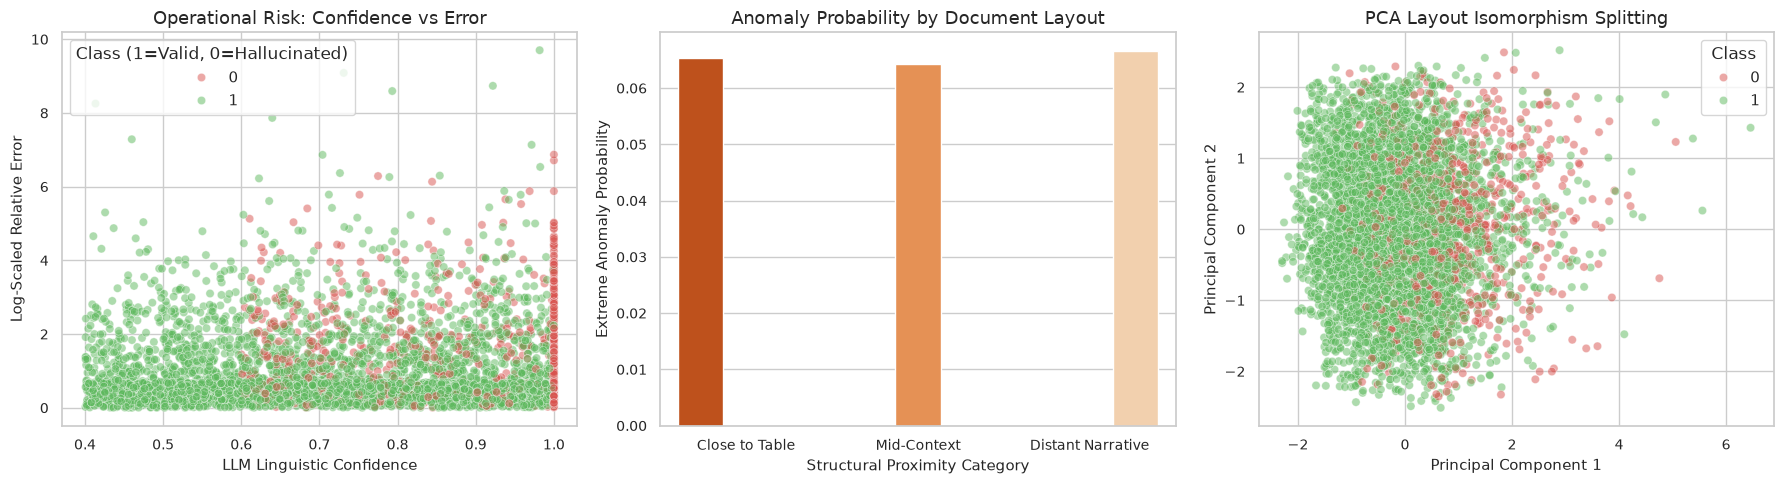

--- Phase 5: Initializing Baseline Model & Evaluation ---

=== BASELINE FILTER CLASSIFICATION PROFILE ===
              precision    recall  f1-score   support

           0     0.9643    0.3506    0.5143       154
           1     0.8941    0.9976    0.9430       846

    accuracy                         0.8980      1000
   macro avg     0.9292    0.6741    0.7287      1000
weighted avg     0.9049    0.8980    0.8770      1000

Receiver Operating Characteristic AUC (ROC-AUC): 0.8657
Precision-Recall AUC (PR-AUC): 0.9738



In [17]:
# ==========================================
# 6. PIPELINE RUNNER
# ==========================================

if __name__ == "__main__":
    np.random.seed(42)
    N = 5000
    
    # Simulation Data Generation matching your 5,000 paired data points schema
    raw_mock_data = pd.DataFrame({
        'extracted_metric': np.random.exponential(scale=5000, size=N),
        'actual_metric': np.random.exponential(scale=5000, size=N),
        'linguistic_confidence': np.random.uniform(0.4, 1.0, size=N),
        'table_proximity_score': np.random.uniform(0.0, 100.0, size=N),
        'text_complexity_score': np.random.uniform(6.0, 18.0, size=N),
        'target_label': np.random.choice([0, 1], size=N, p=[0.15, 0.85]) # 15% baseline hallucination rate
    })
    
    # Inject synthetic high-confidence mathematical hallucinations
    mask = raw_mock_data['target_label'] == 0
    raw_mock_data.loc[mask, 'extracted_metric'] *= np.random.uniform(1.6, 5.0, size=mask.sum())
    raw_mock_data.loc[mask, 'linguistic_confidence'] += 0.2
    raw_mock_data.loc[raw_mock_data['linguistic_confidence'] > 1.0, 'linguistic_confidence'] = 1.0
    
    # Run structural pipeline phases sequentially
    cleaned_df = clean_financial_dataset(raw_mock_data)
    outlier_df = isolate_and_analyze_outliers(cleaned_df)
    engineered_df = engineer_verification_features(outlier_df)
    generate_exploratory_plots(engineered_df)
    
    model_features = ['log_numerical_delta_rel', 'linguistic_confidence', 'table_proximity_score', 'text_complexity_score', 'confidence_complexity_ratio']
    trained_baseline = deploy_baseline_filter(engineered_df, model_features)